# Sentiment Analysis


In [1]:
!pip install gensim

# 1. Import dan Setup

In [2]:
# --- Imports & Setup ---
import os, re, html, unicodedata
from string import punctuation
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# gensim
from gensim.models import Word2Vec, FastText, KeyedVectors

# sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

# tensorflow / keras (for deep models)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, LSTM, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

# nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# 2. Import Data

In [3]:
import requests
import zipfile
import glob

url = f"https://drive.google.com/uc?export=download&id=1edTm4a2u_--1OMV0wmKbDMpt82EJCQMN"
r = requests.get(url)
open('dataset.zip', 'wb').write(r.content)
with zipfile.ZipFile('dataset.zip', 'r') as z:
    z.extractall('dataset')
files = glob.glob('dataset/**/*', recursive=True)
files = [f for f in files if f.endswith(('.csv','.tsv','.txt'))]
files[:20]

['dataset/train.csv', 'dataset/sample_submission.csv', 'dataset/test.csv']

In [4]:
files = glob.glob('dataset/**/*', recursive=True)
csvs = [f for f in files if f.endswith('.csv')]
if len(csvs) == 0:
    csvs = [f for f in files if f.endswith('.tsv') or f.endswith('.txt')]
path = 'dataset/train.csv'
path2 = 'dataset/test.csv'
try:
    train = pd.read_csv(path)
    test = pd.read_csv(path2)
except Exception as e:
    try:
        train = pd.read_csv(path, sep='\t')
    except Exception as e2:
        train = pd.read_csv(path, sep=';', encoding='latin1')
print('Train shape:', train.shape)
print('Test shape:', test.shape)
display(train.head())

Train shape: (586, 3)
Test shape: (146, 2)


,id,Text,Sentiment
0,1,Exploring the world of digital art. It's never...,Negative
1,2,Feeling inspired after attending a workshop.,Positive
2,3,"Eyes wide open in the night, fearful shadows d...",Negative
3,4,"A soul weathered by the storm of heartbreak, s...",Negative
4,5,"Attended a wine tasting event, savoring the ri...",Positive


# 3. EDA

Text column: Text Label column: Sentiment


,Text,Sentiment
0,Exploring the world of digital art. It's never...,Negative
1,Feeling inspired after attending a workshop.,Positive
2,"Eyes wide open in the night, fearful shadows d...",Negative
3,"A soul weathered by the storm of heartbreak, s...",Negative
4,"Attended a wine tasting event, savoring the ri...",Positive



Label distribution:


,count
Sentiment,
Negative,493
Positive,93


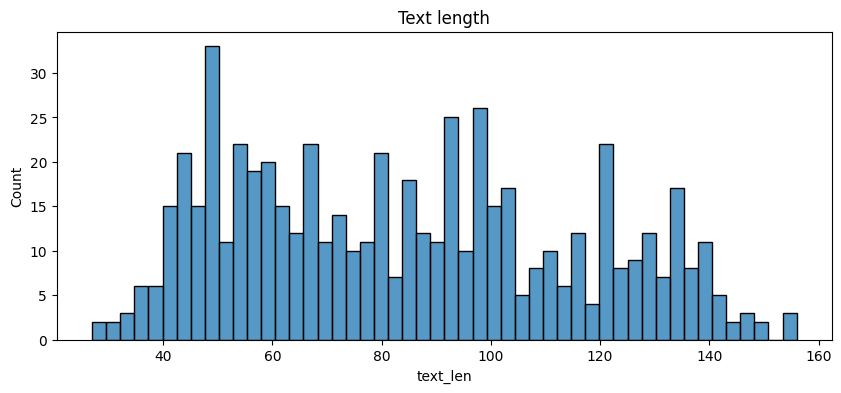

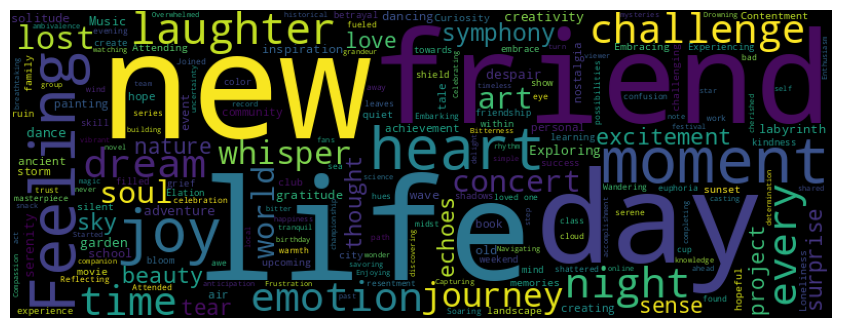


Top unigrams: [('the', 658), ('of', 493), ('in', 235), ('to', 104), ('with', 92), ('and', 86), ('for', 74), ('on', 70), ('by', 56), ('an', 44)]

Top bigrams: [('in the', 145), ('by the', 47), ('of the', 35), ('on the', 33), ('to the', 28), ('for the', 27), ('through the', 20), ('at the', 19), ('as the', 18), ('of life', 17)]


In [5]:
possible_text_cols = ['text','tweet','review','sentence','content','comment','message']
possible_label_cols = ['label','sentiment','target','y']

text_col = next((c for c in train.columns if c.lower() in possible_text_cols), None)
label_col = next((c for c in train.columns if c.lower() in possible_label_cols), None)

if text_col is None or label_col is None:
    print('Could not auto-detect text/label columns. Please set text_col and label_col manually.')
else:
    print('Text column:', text_col, 'Label column:', label_col)
    display(train[[text_col, label_col]].head())
    print('\nLabel distribution:')
    display(train[label_col].value_counts())

    # text length
    train['text_len'] = train[text_col].astype(str).map(len)
    plt.figure(figsize=(10,4)); sns.histplot(train['text_len'], bins=50); plt.title('Text length'); plt.show()

    # word cloud
    corpus = ' '.join(train[text_col].astype(str).tolist())
    wc = WordCloud(width=800, height=300).generate(corpus)
    plt.figure(figsize=(12,4)); plt.imshow(wc); plt.axis('off'); plt.show()

    # top ngrams
    def top_ngrams(corpus, n=20, ngram_range=(1,1)):
        vec = CountVectorizer(ngram_range=ngram_range, max_features=10000).fit(corpus)
        bag = vec.transform(corpus)
        sums = bag.sum(axis=0)
        words = [(word, sums[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_sorted = sorted(words, key=lambda x: x[1], reverse=True)
        return words_sorted[:n]
    print('\nTop unigrams:', top_ngrams(train[text_col].astype(str).tolist(), n=20, ngram_range=(1,1))[:10])
    print('\nTop bigrams:', top_ngrams(train[text_col].astype(str).tolist(), n=20, ngram_range=(2,2))[:10])

# 4. Pre Processing

In [6]:
!pip install emoji


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.9 MB/s eta 0:00:00


In [7]:
import re, html, unicodedata, emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from string import punctuation
nltk.download('punkt_tab')

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# negation tokens
NEGATION_TOKENS = set([
    'not','no','never','none','nobody','nothing','nowhere',
    'neither','nor','cannot',"can't","won't","doesn't"
])

CONTRACTIONS = {
    "n't": ' not', "'re": ' are', "'s": ' is', "'d": ' would',
    "'ll": ' will', "'t": ' not', "'ve": ' have', "'m": ' am'
}

def clean_text(text,
               lowercase=True,
               remove_html=True,
               remove_urls=True,
               remove_mentions=True,
               remove_numbers=False,
               remove_punct=True,
               expand_contractions=True,
               handle_repeat=True,
               handle_emoji=True):
    if pd.isnull(text):
        return ''
    s = str(text)
    s = html.unescape(s)
    s = unicodedata.normalize('NFKC', s)

    if lowercase:
        s = s.lower()
    if remove_html:
        s = re.sub(r'<[^>]+>', ' ', s)
    if remove_urls:
        s = re.sub(r'http\S+|www\.\S+', ' ', s)
    if remove_mentions:
        s = re.sub(r'@\w+', ' ', s)
    if expand_contractions:
        for k, v in CONTRACTIONS.items():
            s = s.replace(k, v)
    if remove_numbers:
        s = re.sub(r'\d+', ' ', s)
    if remove_punct:
        s = re.sub(f"[{re.escape(punctuation)}]", ' ', s)
    if handle_repeat:
        # batasi huruf berulang jadi maksimal 2 (soooo -> soo)
        s = re.sub(r'(.)\1{2,}', r'\1\1', s)
    if handle_emoji:
        # ubah emoji jadi teks (:smile:)
        s = emoji.demojize(s, delimiters=(":", ":"))
    s = re.sub(r'\s+', ' ', s).strip()
    return s


def tokenize_and_lemmatize(text, do_lemmatize=True, remove_stopwords=False):
    tokens = word_tokenize(text)
    out = []
    neg = False
    for t in tokens:
        if t in NEGATION_TOKENS:
            neg = True
            out.append(t)
            continue
        lemma = lemmatizer.lemmatize(t) if do_lemmatize else t
        if remove_stopwords and (lemma in stop_words and lemma not in NEGATION_TOKENS):
            continue
        if neg:
            lemma = lemma + '_NEG'
            neg = False
        out.append(lemma)
    return out


def preprocess_texts(series, remove_stopwords=False):
    texts = series.astype(str).fillna('')
    cleaned = texts.map(lambda x: clean_text(x))
    tokenized = cleaned.map(lambda x: ' '.join(
        tokenize_and_lemmatize(x, remove_stopwords=remove_stopwords)))
    return cleaned, tokenized


clean_with, tokenized_with = preprocess_texts(train[text_col], remove_stopwords=False)
clean_nostop, tokenized_nostop = preprocess_texts(train[text_col], remove_stopwords=True)

train['clean_stop'] = clean_with
train['clean_nostop'] = clean_nostop
train['token_stop'] = tokenized_with
train['token_nostop'] = tokenized_nostop

print('Preprocessing applied. Example:')
display(train[[text_col, 'clean_stop', 'token_stop']].head())


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Preprocessing applied. Example:


,Text,clean_stop,token_stop
0,Exploring the world of digital art. It's never...,exploring the world of digital art it is never...,exploring the world of digital art it is never...
1,Feeling inspired after attending a workshop.,feeling inspired after attending a workshop,feeling inspired after attending a workshop
2,"Eyes wide open in the night, fearful shadows d...",eyes wide open in the night fearful shadows da...,eye wide open in the night fearful shadow danc...
3,"A soul weathered by the storm of heartbreak, s...",a soul weathered by the storm of heartbreak se...,a soul weathered by the storm of heartbreak se...
4,"Attended a wine tasting event, savoring the ri...",attended a wine tasting event savoring the ric...,attended a wine tasting event savoring the ric...


In [8]:
label_col = label_col or 'label'
train = train.dropna(subset=[label_col])
le_map = {v:i for i,v in enumerate(sorted(train[label_col].unique()))}
train['Sentiment_encoded'] = train[label_col].map(le_map)
print('Label mapping:', le_map)

texts_all = {
    'with_stopwords': train['token_stop'].astype(str),
    'no_stopwords': train['token_nostop'].astype(str)
}
labels = train['Sentiment_encoded']

Label mapping: {'Negative': 0, 'Positive': 1}


# 5. Feature Extraction

In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

def build_bow(train_texts, val_texts, max_features=20000):
    vec = CountVectorizer(max_features=max_features)
    X_train = vec.fit_transform(train_texts)
    X_val = vec.transform(val_texts)
    return X_train, X_val, vec

def build_tfidf(train_texts, val_texts, max_features=20000, ngram_range=(1,1)):
    vec = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
    X_train = vec.fit_transform(train_texts)
    X_val = vec.transform(val_texts)
    return X_train, X_val, vec

def build_svd_pipeline(train_texts, val_texts, method='tfidf', n_components=200, ngram_range=(1,1)):
    if method=='bow':
        vec = CountVectorizer(max_features=20000)
    else:
        vec = TfidfVectorizer(max_features=20000, ngram_range=ngram_range)
    X_train = vec.fit_transform(train_texts)
    X_val = vec.transform(val_texts)
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_train_svd = svd.fit_transform(X_train)
    X_val_svd = svd.transform(X_val)
    return X_train_svd, X_val_svd, (vec, svd)

# Word2Vec train & transform
def train_word2vec_and_get_vectors(tokenized_train, tokenized_val, vector_size=100, window=5, min_count=1, epochs=10, sg=1):
    sentences = [t.split() for t in tokenized_train]
    model = Word2Vec(sentences=sentences, vector_size=vector_size, window=window, min_count=min_count, sg=sg, workers=os.cpu_count())
    model.train(sentences, total_examples=len(sentences), epochs=epochs)
    def doc_vectors(token_series):
        out = []
        for txt in token_series:
            words = txt.split()
            vecs = [model.wv[w] for w in words if w in model.wv]
            if len(vecs)==0:
                out.append(np.zeros(vector_size))
            else:
                out.append(np.mean(vecs, axis=0))
        return np.vstack(out)
    X_train = doc_vectors(tokenized_train)
    X_val = doc_vectors(tokenized_val)
    return model, X_train, X_val

# FastText train & transform
def train_fasttext_and_get_vectors(tokenized_train, tokenized_val, vector_size=100, window=5, min_count=1, epochs=10):
    sentences = [t.split() for t in tokenized_train]
    model = FastText(sentences=sentences, vector_size=vector_size, window=window, min_count=min_count, workers=os.cpu_count())
    model.train(sentences, total_examples=len(sentences), epochs=epochs)
    def doc_vectors(token_series):
        out = []
        for txt in token_series:
            words = txt.split()
            vecs = [model.wv[w] for w in words if w in model.wv]
            if len(vecs)==0:
                out.append(np.zeros(vector_size))
            else:
                out.append(np.mean(vecs, axis=0))
        return np.vstack(out)
    X_train = doc_vectors(tokenized_train)
    X_val = doc_vectors(tokenized_val)
    return model, X_train, X_val



In [10]:
def load_glove_vectors(path, embed_dim=100):
    embeddings_index = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype="float32")
            embeddings_index[word] = coefs
    return embeddings_index

def build_glove_vectors(texts_train, texts_val, tokenizer, embeddings_index, embed_dim=100, max_len=200):
    seq_train = tokenizer.texts_to_sequences(texts_train)
    seq_val = tokenizer.texts_to_sequences(texts_val)
    X_train_pad = pad_sequences(seq_train, maxlen=max_len, padding='post')
    X_val_pad = pad_sequences(seq_val, maxlen=max_len, padding='post')
    def avg_embed(X_pad):
        vecs = []
        for seq in X_pad:
            word_vecs = []
            for idx in seq:
                if idx == 0:
                    continue
                word = list(tokenizer.word_index.keys())[list(tokenizer.word_index.values()).index(idx)]
                if word in embeddings_index:
                    word_vecs.append(embeddings_index[word])
            if len(word_vecs) > 0:
                vecs.append(np.mean(word_vecs, axis=0))
            else:
                vecs.append(np.zeros(embed_dim))
        return np.array(vecs)

    return avg_embed(X_train_pad), avg_embed(X_val_pad)


# 6. Main Program

In [ ]:
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Train & evaluate deep models
def train_eval_deep(model, X_tr, y_tr, X_val, y_val, epochs=10, batch_size=32):
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    preds = model.predict(X_val).argmax(axis=1)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="macro")
    print(classification_report(y_val, preds, zero_division=0))
    return hist, acc, f1

# Deep model builders with dropout
def build_cnn_seq(num_words, embed_dim, max_len, num_classes, embedding_matrix=None, trainable_embed=False):
    model = models.Sequential()
    if embedding_matrix is not None:
        model.add(layers.Embedding(num_words, embed_dim, weights=[embedding_matrix],
                                   input_length=max_len, trainable=trainable_embed))
    else:
        model.add(layers.Embedding(num_words, embed_dim, input_length=max_len))
    model.add(layers.Conv1D(128, 5, activation='relu'))
    model.add(layers.GlobalMaxPooling1D())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_rnn_seq(num_words, embed_dim, max_len, num_classes, embedding_matrix=None, trainable_embed=False):
    model = models.Sequential()
    if embedding_matrix is not None:
        model.add(layers.Embedding(num_words, embed_dim, weights=[embedding_matrix],
                                   input_length=max_len, trainable=trainable_embed))
    else:
        model.add(layers.Embedding(num_words, embed_dim, input_length=max_len))
    model.add(layers.SimpleRNN(128))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_lstm_seq(num_words, embed_dim, max_len, num_classes, embedding_matrix=None, trainable_embed=False):
    model = models.Sequential()
    if embedding_matrix is not None:
        model.add(layers.Embedding(num_words, embed_dim, weights=[embedding_matrix],
                                   input_length=max_len, trainable=trainable_embed))
    else:
        model.add(layers.Embedding(num_words, embed_dim, input_length=max_len))
    model.add(layers.LSTM(128))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


# ================== MAIN LOOP ==================
results_all = []

# Split data into training and validation sets
X_train_texts, X_val_texts, y_train, y_val = train_test_split(
    texts_all['with_stopwords'], labels, test_size=0.2, random_state=42, stratify=labels
)

## 1. Classical + SVD
for feat_name, method, ngram in [
    ("BoW-SVD", "bow", (1,1)),
    ("TFIDF-SVD", "tfidf", (1,2))
]:
    Xtr_svd, Xval_svd, _ = build_svd_pipeline(
        X_train_texts, X_val_texts,
        method=method,
        n_components=200,
        ngram_range=ngram
    )

    for model_name, clf in [
        ("SVM", LinearSVC(max_iter=2000)),
        ("LogReg", LogisticRegression(max_iter=2000)),
        ("KNN", KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski'))
    ]:
        clf.fit(Xtr_svd, y_train)
        preds = clf.predict(Xval_svd)
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds, average="macro")
        results_all.append({"Feature": feat_name,
                            "Model": model_name,
                            "Accuracy": acc,
                            "Macro F1": f1})


## 2. Pretrained Embeddings + Deep Learning
import gensim.downloader as api

# Word2Vec Google News
wv_w2v = api.load("word2vec-google-news-300")
# FastText
wv_ft = api.load("fasttext-wiki-news-subwords-300")
# GloVe
wv_glove = api.load("glove-wiki-gigaword-300")

# Tokenizers
tokenizer_w2v = Tokenizer(num_words=30000, oov_token="<OOV>")
tokenizer_w2v.fit_on_texts(X_train_texts.tolist())

tokenizer_ft = Tokenizer(num_words=30000, oov_token="<OOV>")
tokenizer_ft.fit_on_texts(X_train_texts.tolist())

tokenizer_glove = Tokenizer(num_words=30000, oov_token="<OOV>")
tokenizer_glove.fit_on_texts(X_train_texts.tolist())


def build_embedding_matrix_from_wv(tokenizer, wv, emb_dim=300):
    word_index = tokenizer.word_index
    num_words = len(word_index) + 1
    embedding_matrix = np.zeros((num_words, emb_dim))
    for word, i in word_index.items():
        if word in wv:
            embedding_matrix[i] = wv[word]
    return embedding_matrix

embedding_matrix_w2v = build_embedding_matrix_from_wv(tokenizer_w2v, wv_w2v, 300)
embedding_matrix_ft = build_embedding_matrix_from_wv(tokenizer_ft, wv_ft, 300)
embedding_matrix_glove = build_embedding_matrix_from_wv(tokenizer_glove, wv_glove, 300)

for emb_name, embedding_matrix, tokenizer in [
    ("Word2Vec", embedding_matrix_w2v, tokenizer_w2v),
    ("FastText", embedding_matrix_ft, tokenizer_ft),
    ("GloVe", embedding_matrix_glove, tokenizer_glove)
]:
    max_len = 200
    X_tr_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_texts), maxlen=max_len, padding='post')
    X_val_pad = pad_sequences(tokenizer.texts_to_sequences(X_val_texts), maxlen=max_len, padding='post')

    num_words = embedding_matrix.shape[0]
    embed_dim = embedding_matrix.shape[1]
    num_classes = len(np.unique(labels))

    for name, builder in [("CNN", build_cnn_seq), ("RNN", build_rnn_seq), ("LSTM", build_lstm_seq)]:
        print(f"\n=== Training {emb_name} + {name} ===")
        model = builder(num_words, embed_dim, max_len, num_classes,
                        embedding_matrix=embedding_matrix,
                        trainable_embed=True)
        hist, acc, f1 = train_eval_deep(model, X_tr_pad, np.array(y_train),
                                        X_val_pad, np.array(y_val),
                                        epochs=10)
        results_all.append({"Feature": emb_name, "Model": name, "Accuracy": acc, "Macro F1": f1})



# Result
results_df = pd.DataFrame(results_all).sort_values(by="Macro F1", ascending=False)
print("\n=== FINAL RESULTS ===")
print(results_df.to_string(index=False))

[==------------------------------------------------] 5.4% 89.2/1662.8MB downloaded